# Trash Classification using ResNet and Transfer Learning

The dataset used includes images of some target trash we are trying to classify.

## Import Necessary Libraries

In [1]:
# Import Data Science Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from datasets import load_dataset
from datasets import load_from_disk

/Users/dipti/mambaforge/envs/computer_vision/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Tensorflow Libraries
from tensorflow import keras
from tensorflow.keras import layers,models
from keras.utils import image_dataset_from_directory
from keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Model
from tensorflow.keras.layers import Resizing, Rescaling
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

In [3]:
print(tf.__version__)
print(keras.__version__)

2.10.0
2.10.0


In [4]:
# System libraries
from pathlib import Path
import os.path
from PIL import Image

In [9]:
# Metrics
from sklearn.metrics import classification_report, confusion_matrix
import itertools

## Create helper functions

In [ ]:
# !wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py

# Import series of helper functions for our notebook
from helper_functions import create_tensorboard_callback, plot_loss_curves, unzip_data, compare_historys, walk_through_dir, pred_and_plot

## Load and transform data

In [ ]:
BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)

## Data Preprocessing
The data will be split into three different categories: Training, Validation and Testing. The training data will be used to train the deep learning CNN model and its parameters will be fine tuned with the validation data. Finally, the performance of the data will be evaluated using the test data (data the model has not previously seen).</br>
The data is first loaded from a Hugging Face repository (https://huggingface.co/datasets/dvk65/TrashTypes) where it is stored in a parquet format because of its huge size (2.11 GB). It is then normalized by converting it to a np.array format with dtype uint8. These normalized images are then converted to a Tensorflow compatible format and used for model training.</br>
**The steps of loading from dataset and preprocessing can be skipped. They are very time consuming because of the mapping step. The data acquired after these steps can be loaded directly using the load_from_disk function.**

In [8]:
# dataset = load_dataset("dvk65/TrashTypes", split="train")
# label_names = dataset.features["label"].names
# print(label_names)

# # Create 80/10/10 split
# dataset = dataset.train_test_split(test_size=0.2, seed=123)
# train_test = dataset['train']
# temp_test = dataset['test']

# # Split temp_test into 50/50 → val / test
# temp_test = temp_test.train_test_split(test_size=0.5, seed=123)

# train_ds = train_test
# val_ds = temp_test['train']
# test_ds = temp_test['test']

# print(train_ds, val_ds, test_ds)

['apples', 'bananas', 'bottles', 'cans', 'cardboard', 'cups', 'eggshells', 'generalcompost', 'mixers', 'peels', 'plasticbags', 'plastics', 'tissues']
Dataset({
    features: ['image', 'label'],
    num_rows: 11720
}) Dataset({
    features: ['image', 'label'],
    num_rows: 1465
}) Dataset({
    features: ['image', 'label'],
    num_rows: 1466
})


In [9]:
# def preprocess(example):
#     img = example["image"]

#     # Standardize input types
#     if isinstance(img, Image.Image):
#         pass  # already PIL
#     elif isinstance(img, dict) and "bytes" in img:
#         img = Image.open(io.BytesIO(img["bytes"]))
#     else:
#         img = Image.fromarray(np.array(img).astype("uint8"))

#     # Force RGB mode
#     img = img.convert("RGB")

#     # Resize now (before batching)
#     img = img.resize(IMAGE_SIZE)

#     example["image"] = np.array(img, dtype=np.uint8)
#     return example

# train_ds = train_ds.map(preprocess, num_proc=8)
# print("Train Datasets converted to TF from Parquet")
# val_ds = val_ds.map(preprocess, num_proc=8)
# print("Validation Datasets converted to TF from Parquet")
# test_ds = test_ds.map(preprocess, num_proc=8)
# print("Test Datasets converted to TF from Parquet")

Map (num_proc=8):   0%|          | 0/11720 [00:00<?, ? examples/s]

/opt/miniconda/envs/eai/lib/python3.10/site-packages/datasets/features/image.py:338: UserWarning: Downcasting array dtype int64 to uint8 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")
/opt/miniconda/envs/eai/lib/python3.10/site-packages/datasets/features/image.py:338: UserWarning: Downcasting array dtype int64 to uint8 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")
/opt/miniconda/envs/eai/lib/python3.10/site-packages/datasets/features/image.py:338: UserWarning: Downcasting array dtype int64 to uint8 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")
/opt/miniconda/envs/eai/lib/python3.10/site-packages/datasets/features/image.py:338: UserWarning: Downcasting array dtype int64 to uint8 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting a

Train Datasets converted to TF from Parquet


Map (num_proc=8):   0%|          | 0/1465 [00:00<?, ? examples/s]

/opt/miniconda/envs/eai/lib/python3.10/site-packages/datasets/features/image.py:338: UserWarning: Downcasting array dtype int64 to uint8 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")
/opt/miniconda/envs/eai/lib/python3.10/site-packages/datasets/features/image.py:338: UserWarning: Downcasting array dtype int64 to uint8 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")
/opt/miniconda/envs/eai/lib/python3.10/site-packages/datasets/features/image.py:338: UserWarning: Downcasting array dtype int64 to uint8 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")
/opt/miniconda/envs/eai/lib/python3.10/site-packages/datasets/features/image.py:338: UserWarning: Downcasting array dtype int64 to uint8 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting a

Validation Datasets converted to TF from Parquet


Map (num_proc=8):   0%|          | 0/1466 [00:00<?, ? examples/s]

/opt/miniconda/envs/eai/lib/python3.10/site-packages/datasets/features/image.py:338: UserWarning: Downcasting array dtype int64 to uint8 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")
/opt/miniconda/envs/eai/lib/python3.10/site-packages/datasets/features/image.py:338: UserWarning: Downcasting array dtype int64 to uint8 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")
/opt/miniconda/envs/eai/lib/python3.10/site-packages/datasets/features/image.py:338: UserWarning: Downcasting array dtype int64 to uint8 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting array dtype {dtype} to {dest_dtype} to be compatible with 'Pillow'")
/opt/miniconda/envs/eai/lib/python3.10/site-packages/datasets/features/image.py:338: UserWarning: Downcasting array dtype int64 to uint8 to be compatible with 'Pillow'
  warnings.warn(f"Downcasting a

Test Datasets converted to TF from Parquet


In [10]:
# train_ds.save_to_disk("train_processed")
# val_ds.save_to_disk("val_processed")
# test_ds.save_to_disk("test_processed")
# The error does not mean data is not saved locally. It is a Jupyter Notebook display issue.

Saving the dataset (0/2 shards):   0%|          | 0/11720 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1465 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1466 [00:00<?, ? examples/s]

In [7]:
train_ds = load_from_disk("train_processed")
val_ds = load_from_disk("val_processed")
test_ds = load_from_disk("test_processed")

In [8]:
train_ds.features["label"].names

['apples',
 'bananas',
 'bottles',
 'cans',
 'cardboard',
 'cups',
 'eggshells',
 'generalcompost',
 'mixers',
 'peels',
 'plasticbags',
 'plastics',
 'tissues']

In [10]:
def to_tf(ds): # use map to resize before batching, with_transform for resizing after batching (with_transform can cause errors)
    return ds.to_tf_dataset(
        columns="image",
        label_cols="label",
        batch_size=BATCH_SIZE,
        shuffle=True,
        prefetch = tf.data.AUTOTUNE
    )

tf_train = to_tf(train_ds)
print("Train Datasets converted to TF from Parquet")
tf_val = to_tf(val_ds)
print("Validation Datasets converted to TF from Parquet")
tf_test = to_tf(test_ds)
print("Test Datasets converted to TF from Parquet")

print("Datasets converted to TF from Parquet")

Train Datasets converted to TF from Parquet
Validation Datasets converted to TF from Parquet
Test Datasets converted to TF from Parquet
Datasets converted to TF from Parquet


In [10]:
def resize_normalize(images, labels):
    images = tf.image.resize(images, IMAGE_SIZE)
    images = tf.cast(images, tf.float32) / 255.0
    return images, labels

tf_train = tf_train.map(resize_normalize, num_parallel_calls=tf.data.AUTOTUNE)
tf_val = tf_val.map(resize_normalize, num_parallel_calls=tf.data.AUTOTUNE)
tf_test = tf_test.map(resize_normalize, num_parallel_calls=tf.data.AUTOTUNE)

In [11]:
# Verifying shape

batch_img, batch_label = next(iter(tf_train))
batch_img.shape, batch_label.shape

(TensorShape([32, 224, 224, 3]), TensorShape([32]))

### Placing data into a Dataframe
The first column `filepaths` contains the file path location of each individual images. The second column `labels`, on the other hand, contains the class label of the corresponding image from the file path

In [13]:
# bad_files = []

# print(f"Checking {len(filepaths)} images...")

# for fp in filepaths:
#     path = str(fp)
#     try:
#         # Read bytes from disk
#         img_bytes = tf.io.read_file(path)

#         # Try to decode using TensorFlow
#         _ = tf.image.decode_image(img_bytes, channels=3)
#         # print(f"✅ {path} is a valid image")

#     except Exception as e:
#         print(f"⚠️  Unreadable image: {path}")
#         print(f"    Error: {e}")
#         bad_files.append(path)

# print(f"\nTotal unreadable files: {len(bad_files)}")

### Visualizing images from the dataset

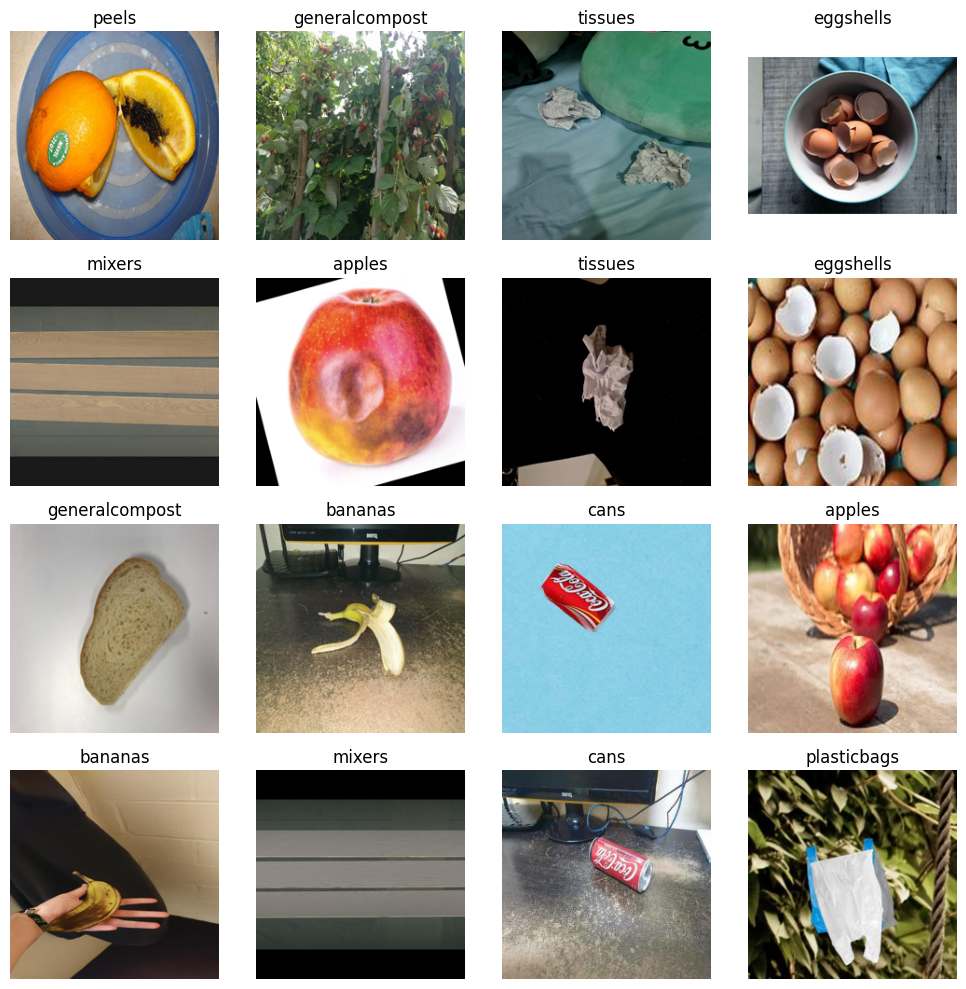

In [12]:
label_names = train_ds.features["label"].names   # reuse the same metadata

# Get one batch from the TF dataset
images, labels = next(iter(tf_train))

# Pick the first 16 samples
num_show = 16
images = images[:num_show]
labels = labels[:num_show]

# Plot
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
axes = axes.flatten()

for i in range(num_show):
    axes[i].imshow(images[i].numpy())   # Convert tensor → numpy for plotting
    axes[i].set_title(label_names[int(labels[i])])
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Training the model
The model images will be subjected to a pre-trained model called ResNet50. Three callbacks will be utilized to monitor the training. These are: Model Checkpoint, Early Stopping, Tensorboard callback. The summary of the model hyperparameter is shown as follows:

**Batch size** : 32

**Epochs** : 20

**Input Shape** : (224, 224, 3)

**Output layer** : 13



### Training the model

In [19]:
preprocess_layer = tf.keras.layers.Lambda(preprocess_input)

def build_model():
    pretrained_model = ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
    )

    pretrained_model.trainable = False  # Phase 1: freeze backbone

    inputs = Input(shape=(*IMAGE_SIZE, 3))
    x = tf.keras.layers.Resizing(*IMAGE_SIZE)(inputs)
    x = preprocess_layer(x)  # standardized input pipeline

    x = pretrained_model(x, training=False)

    # Fully connected classifier head
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.2)(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.2)(x)

    outputs = Dense(13, activation="softmax")(x)

    model = Model(inputs, outputs)
    return model

In [20]:
# Phase 1
# Uses features ResNet has from imagenet (edges, shapes, textures, etc) to map them to our targets

model = build_model()

model.compile(
    optimizer=Adam(0.0001),
    loss="sparse_categorical_crossentropy", # labels do not have to be one-hot encoded. Helps with faster processing
    metrics=["accuracy"]
)

callbacks_phase1 = [
    EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True, mode="max"),
    ModelCheckpoint("checkpoints/resnet_phase1.keras", save_best_only=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, verbose=1)
]

history1 = model.fit(
    tf_train,
    validation_data=tf_val,
    epochs=20,
    callbacks=callbacks_phase1
)

Epoch 1/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 224s 595ms/step - accuracy: 0.5646 - loss: 1.4512 - val_accuracy: 0.9324 - val_loss: 0.2219 - learning_rate: 1.0000e-04
Epoch 2/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 216s 589ms/step - accuracy: 0.9293 - loss: 0.2430 - val_accuracy: 0.9577 - val_loss: 0.1306 - learning_rate: 1.0000e-04
Epoch 3/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 216s 588ms/step - accuracy: 0.9561 - loss: 0.1483 - val_accuracy: 0.9611 - val_loss: 0.1090 - learning_rate: 1.0000e-04
Epoch 4/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 216s 589ms/step - accuracy: 0.9712 - loss: 0.1016 - val_accuracy: 0.9700 - val_loss: 0.0977 - learning_rate: 1.0000e-04
Epoch 5/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 216s 589ms/step - accuracy: 0.9763 - loss: 0.0769 - val_accuracy: 0.9652 - val_loss: 0.0943 - learning_rate: 1.0000e-04
Epoch 6/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 216s 588ms/step - accuracy: 0.9828 - loss: 0.0591 - val_accuracy: 0.9727 - val_loss: 0.0804 - learning_rate: 1.0000e-04
Epoch 7/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 

In [23]:
# Phase 2
# Specializes the dataset for our dataset by training deeper layers

# Unfreeze deeper layers
model.layers[3].trainable = True  # ResNet50 backbone

for layer in model.layers[3].layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=Adam(0.00001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_phase2 = [
    EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True, mode="max"),
    ModelCheckpoint("checkpoints/resnet_phase2.keras", save_best_only=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=1, verbose=1) # learning rate scheduler that reduces learning rate when monitored metric(val_loss) stops improving
]

history2 = model.fit(
    tf_train,
    validation_data=tf_val,
    epochs=20,
    callbacks=callbacks_phase2
)

Epoch 1/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 318s 839ms/step - accuracy: 0.9941 - loss: 0.0202 - val_accuracy: 0.9816 - val_loss: 0.0561 - learning_rate: 1.0000e-05
Epoch 2/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 307s 835ms/step - accuracy: 0.9967 - loss: 0.0130 - val_accuracy: 0.9863 - val_loss: 0.0476 - learning_rate: 1.0000e-05
Epoch 3/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 766ms/step - accuracy: 0.9972 - loss: 0.0098
Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
367/367 ━━━━━━━━━━━━━━━━━━━━ 306s 833ms/step - accuracy: 0.9972 - loss: 0.0098 - val_accuracy: 0.9877 - val_loss: 0.0483 - learning_rate: 1.0000e-05
Epoch 4/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 306s 834ms/step - accuracy: 0.9991 - loss: 0.0058 - val_accuracy: 0.9891 - val_loss: 0.0463 - learning_rate: 2.0000e-06
Epoch 5/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 306s 834ms/step - accuracy: 0.9998 - loss: 0.0048 - val_accuracy: 0.9870 - val_loss: 0.0460 - learning_rate: 2.0000e-06
Epoch 6/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 307s 8

## Model Evaluation
The test dataset will be used to evaluate the performance of the model.One of the metrics that will be tested would be accuracy which measures the fraction of predictions the model got right. Other metrics are as follows:

**Precision(P)**:
The fraction of true positives (TP, correct predictions) from the total amount of relevant results, i.e., the sum of TP and false positives (FP). For multi-class classification problems, P is averaged among the classes. The following is the formula for precision.

<center>$P=TP/(TP+FP)$</center>

**Recall(R)**:
The fraction of TP from the total amount of TP and false negatives (FN). For multi-class classification problems, R gets averaged among all the classes. The following is the formula for recall.
<center>$R=TP/(TP+FN)$</center>

**F1 score(F1)**:
The harmonic mean of precision and recall. For multi-class classification problems, F1 gets averaged among all the classes. The following is the formula for F1 score.
<center>$F1=2 * (TP * FP)/(TP+FP)$</center>



In [24]:
# Evaluate model on test dataset
test_loss, test_acc = model.evaluate(tf_test, verbose=1)

print(f"\nTest Results")
print(f"Test Loss : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc * 100:.4f}%")


46/46 ━━━━━━━━━━━━━━━━━━━━ 25s 529ms/step - accuracy: 0.9861 - loss: 0.0422

Test Results
Test Loss : 0.0478
Test Accuracy : 98.2947%


In [25]:
model.save("trashclassify_13.keras")
model.save_weights("trashclassify_weights.weights.h5")
print("Files saved!")

Files saved!


In [26]:
for layer in model.layers:
    print(layer.name, type(layer))

input_layer_6 <class 'keras.src.layers.core.input_layer.InputLayer'>
resizing_2 <class 'keras.src.layers.preprocessing.resizing.Resizing'>
lambda_3 <class 'keras.src.layers.core.lambda_layer.Lambda'>
resnet50 <class 'keras.src.models.functional.Functional'>
dense_6 <class 'keras.src.layers.core.dense.Dense'>
dropout_4 <class 'keras.src.layers.regularization.dropout.Dropout'>
dense_7 <class 'keras.src.layers.core.dense.Dense'>
dropout_5 <class 'keras.src.layers.regularization.dropout.Dropout'>
dense_8 <class 'keras.src.layers.core.dense.Dense'>


### Visualizing loss curves

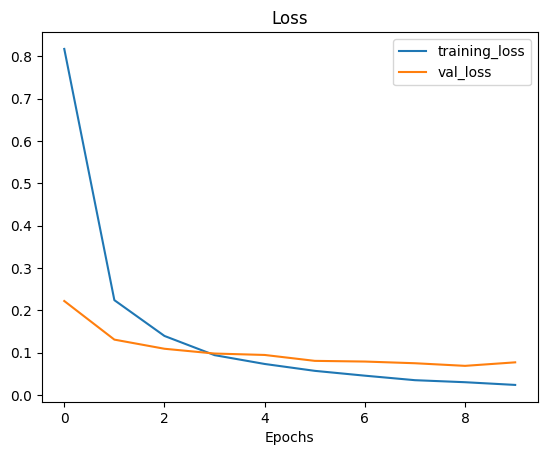

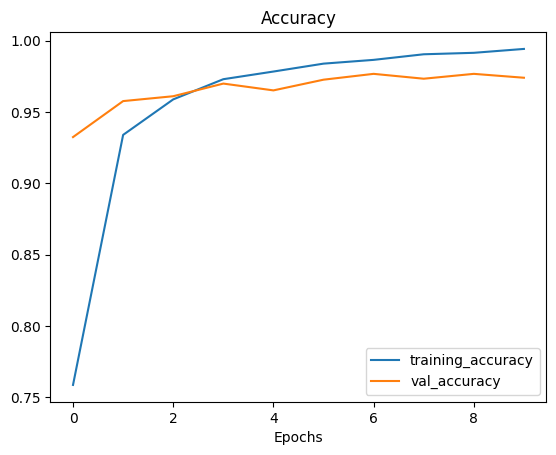

In [27]:
plot_loss_curves(history1)

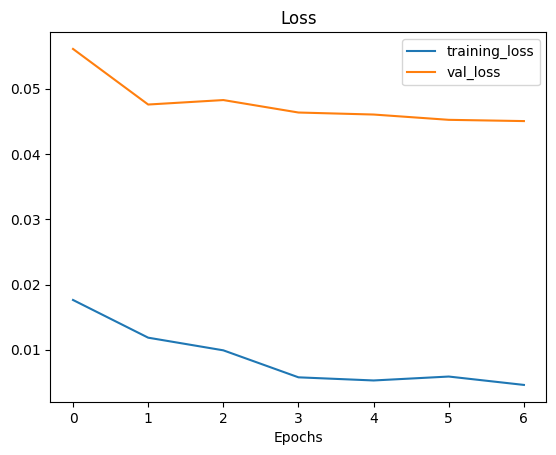

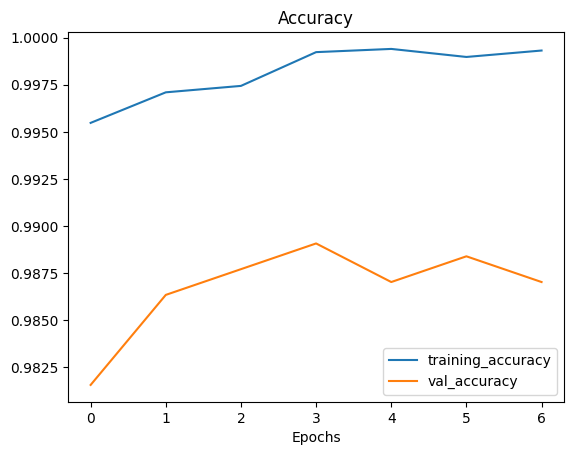

In [28]:
plot_loss_curves(history2)

### Making predictions on the test data

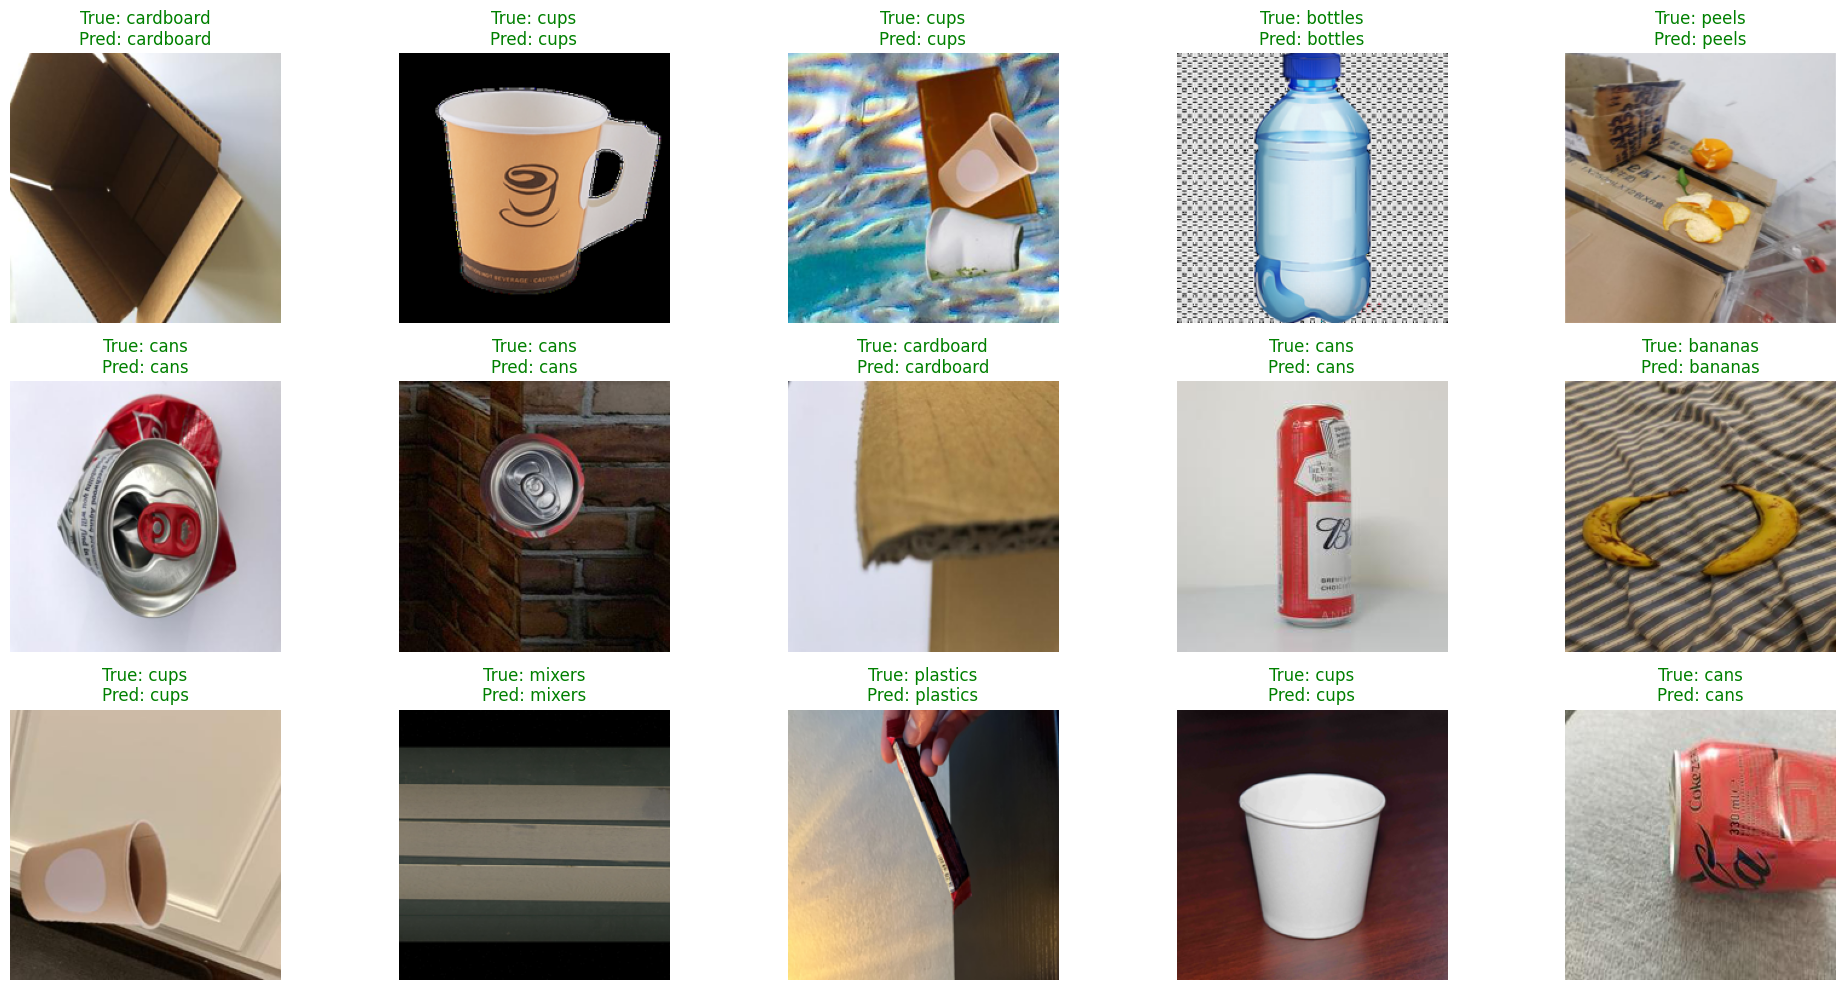

2025-12-09 15:13:06.224766: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [30]:
# Display 25 random pictures from the dataset with their labels
# Take one batch of images and labels

y_true = []
y_pred = []

for images, labels in tf_test.take(1): # 1 specifies 1 batch of 32 images since that is our batch size. len(test_ds) all test images
    preds = model.predict(images, verbose=0)

    batch_pred = np.argmax(preds, axis=1)
    batch_true = labels.numpy() # if not one-hot encoded
    
    y_pred.extend(batch_pred)
    y_true.extend(batch_true)
    # class_names = test_ds.class_names

    plt.figure(figsize=(20, 10))
    for i in range(min(15, len(images))):  # show first 15 images
        ax = plt.subplot(3, 5, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        color = "green" if batch_pred[i] == batch_true[i] else "red"
        plt.title(f"True: {label_names[batch_true[i]]}\nPred: {label_names[batch_pred[i]]}", color=color)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

### Plotting the classification reports and confusion matrix

In [31]:
# Generate report

print(classification_report(y_true, y_pred, target_names=label_names))

                precision    recall  f1-score   support

        apples       1.00      1.00      1.00         3
       bananas       1.00      1.00      1.00         3
       bottles       1.00      1.00      1.00         1
          cans       1.00      1.00      1.00         5
     cardboard       1.00      1.00      1.00         3
          cups       1.00      1.00      1.00         5
     eggshells       0.67      1.00      0.80         2
generalcompost       0.00      0.00      0.00         1
        mixers       1.00      1.00      1.00         2
         peels       1.00      1.00      1.00         2
   plasticbags       1.00      1.00      1.00         2
      plastics       1.00      1.00      1.00         2
       tissues       1.00      1.00      1.00         1

      accuracy                           0.97        32
     macro avg       0.90      0.92      0.91        32
  weighted avg       0.95      0.97      0.96        32



/home/kulkarni.dip/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/kulkarni.dip/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/kulkarni.dip/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [32]:
def make_confusion_matrix(y_true, y_pred, classes=None, figsize=(15, 7), text_size=10, norm=False, savefig=False):
  """Makes a labelled confusion matrix comparing predictions and ground truth labels.

  If classes is passed, confusion matrix will be labelled, if not, integer class values
  will be used.

  Args:
    y_true: Array of truth labels (must be same shape as y_pred).
    y_pred: Array of predicted labels (must be same shape as y_true).
    classes: Array of class labels (e.g. string form). If `None`, integer labels are used.
    figsize: Size of output figure (default=(10, 10)).
    text_size: Size of output figure text (default=15).
    norm: normalize values or not (default=False).
    savefig: save confusion matrix to file (default=False).

  Returns:
    A labelled confusion matrix plot comparing y_true and y_pred.

  Example usage:
    make_confusion_matrix(y_true=test_labels, # ground truth test labels
                          y_pred=y_preds, # predicted labels
                          classes=class_names, # array of class label names
                          figsize=(15, 15),
                          text_size=10)
  """
  # Create the confustion matrix
  cm = confusion_matrix(y_true, y_pred)
  cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] # normalize it
  n_classes = cm.shape[0] # find the number of classes we're dealing with

  # Plot the figure and make it pretty
  fig, ax = plt.subplots(figsize=figsize)
  cax = ax.matshow(cm, cmap=plt.cm.Blues) # colors will represent how 'correct' a class is, darker == better
  fig.colorbar(cax)

  # Are there a list of classes?
  if classes:
    labels = classes
  else:
    labels = np.arange(cm.shape[0])

  # Label the axes
  ax.set(title="Confusion Matrix",
         xlabel="Predicted label",
         ylabel="True label",
         xticks=np.arange(n_classes), # create enough axis slots for each class
         yticks=np.arange(n_classes),
         xticklabels=labels, # axes will labeled with class names (if they exist) or ints
         yticklabels=labels)

  # Make x-axis labels appear on bottom
  ax.xaxis.set_label_position("bottom")
  ax.xaxis.tick_bottom()
  ### Added: Rotate xticks for readability & increase font size (required due to such a large confusion matrix)
  plt.xticks(rotation=90, fontsize=text_size)
  plt.yticks(fontsize=text_size)

  # Set the threshold for different colors
  threshold = (cm.max() + cm.min()) / 2.

  # Plot the text on each cell
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    if norm:
      plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j]*100:.1f}%)",
              horizontalalignment="center",
              color="white" if cm[i, j] > threshold else "black",
              size=text_size)
    else:
      plt.text(j, i, f"{cm[i, j]}",
              horizontalalignment="center",
              color="white" if cm[i, j] > threshold else "black",
              size=text_size)

  # Save the figure to the current working directory
  if savefig:
    fig.savefig("confusion_matrix.png")


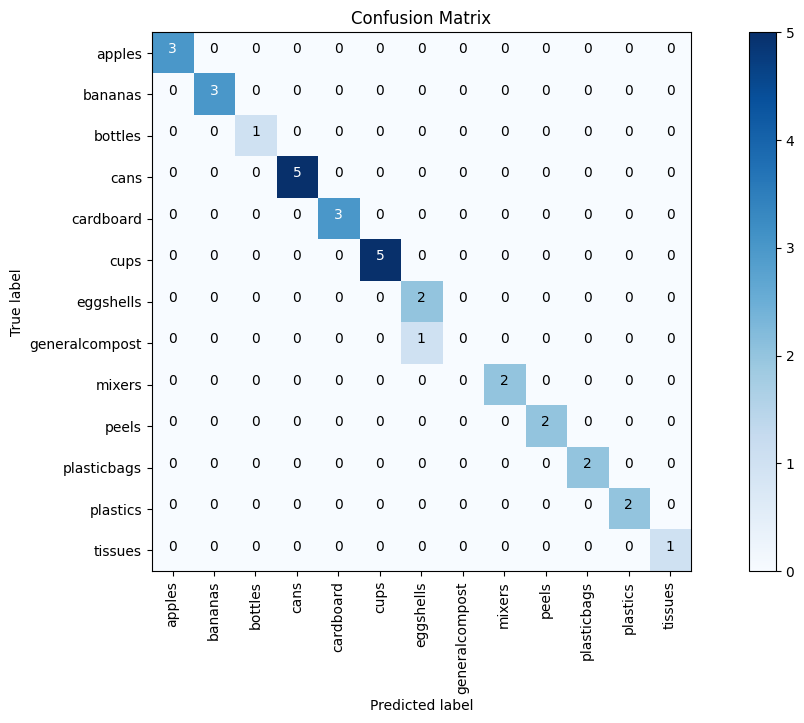

In [33]:
make_confusion_matrix(y_true, y_pred, classes=label_names)

In [ ]:
model = keras.models.load_model("trashclassify_13.keras")  # or .keras

model.summary()
